- ## Ejercicio 2
- a) Repite el análisis que se ha llevado a cabo en el Ejercicio 1 para este nuevo proyecto.

In [1]:
datos = {
    "A":{
        "dur":2, "deps":[]
    },
    "B":{
        "dur":4, "deps":["A"]
    },
    "C":{
        "dur":6, "deps":["B"]
    },
    "D":{
        "dur":3, "deps":["C"]
    },
    "E":{
        "dur":3, "deps":["A"]
    },
    "F":{
        "dur":4, "deps":["D","E"]
    },
    "G":{
        "dur":2, "deps":["F"]
    },
    "H":{
        "dur":3, "deps":["G"]
    },
    "I":{
        "dur":3, "deps":["H"]
    },
}

### IC 

In [2]:
# IC
def calcular_inicio_temprano(datos):
    for tarea,info in datos.items():
        dependencias = info["deps"]

        if not dependencias:
            datos[tarea]["IC"]=0
        else:
            lista_tareas=[]
            for dep in dependencias:
                inicio=datos[dep]["dur"]+datos[dep]["IC"]
                lista_tareas.append(inicio)
            datos[tarea]["IC"]=max(lista_tareas)
calcular_inicio_temprano(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24}}


### TC

In [3]:
# TC
def calcular_final_temprano(datos):
    for tarea,info in datos.items():
        datos[tarea]["TC"]=datos[tarea]["dur"]+datos[tarea]["IC"]
calcular_final_temprano(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6, 'TC': 12}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12, 'TC': 15}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2, 'TC': 5}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15, 'TC': 19}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19, 'TC': 21}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21, 'TC': 24}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24, 'TC': 27}}


### TL

In [4]:
# TL
def depende(datos):
    for tarea,info in datos.items():
        for letra_depende in info["deps"]:
            if letra_depende in datos:
                lista_sucesores=datos[letra_depende].setdefault("sucesores",[])
                
                if tarea not in lista_sucesores:
                    lista_sucesores.append(tarea)
depende(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'E']}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C']}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6, 'TC': 12, 'sucesores': ['D']}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12, 'TC': 15, 'sucesores': ['F']}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2, 'TC': 5, 'sucesores': ['F']}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15, 'TC': 19, 'sucesores': ['G']}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19, 'TC': 21, 'sucesores': ['H']}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21, 'TC': 24, 'sucesores': ['I']}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24, 'TC': 27}}


- Calculamos una función que sea de `sucesores`, para saber quien va siguiente a esa tarea

In [5]:
def calcular_final_tardio(datos):
    for tarea,info in reversed(datos.items()):
        sucesores = info.get("sucesores")

        if not sucesores:
            datos[tarea]["TL"]=datos[tarea]["TC"]

        else:
            lista_sucesores=[]
            for suc in info["sucesores"]:
                il_sucesor=datos[suc]["TL"]-datos[suc]["dur"]
                lista_sucesores.append(il_sucesor)
            datos[tarea]["TL"]=min(lista_sucesores)

calcular_final_tardio(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'E'], 'TL': 2}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6, 'TC': 12, 'sucesores': ['D'], 'TL': 12}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12, 'TC': 15, 'sucesores': ['F'], 'TL': 15}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2, 'TC': 5, 'sucesores': ['F'], 'TL': 15}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15, 'TC': 19, 'sucesores': ['G'], 'TL': 19}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19, 'TC': 21, 'sucesores': ['H'], 'TL': 21}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21, 'TC': 24, 'sucesores': ['I'], 'TL': 24}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24, 'TC': 27, 'TL': 27}}


### IL

In [6]:
# IL
def calcular_final_tardio(datos):
    for tarea,info in reversed(datos.items()):
        datos[tarea]["IL"]=datos[tarea]["TL"]-datos[tarea]["dur"]
calcular_final_tardio(datos)
print(datos)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'E'], 'TL': 2, 'IL': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6, 'IL': 2}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6, 'TC': 12, 'sucesores': ['D'], 'TL': 12, 'IL': 6}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12, 'TC': 15, 'sucesores': ['F'], 'TL': 15, 'IL': 12}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2, 'TC': 5, 'sucesores': ['F'], 'TL': 15, 'IL': 12}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15, 'TC': 19, 'sucesores': ['G'], 'TL': 19, 'IL': 15}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19, 'TC': 21, 'sucesores': ['H'], 'TL': 21, 'IL': 19}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21, 'TC': 24, 'sucesores': ['I'], 'TL': 24, 'IL': 21}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24, 'TC': 27, 'TL': 27, 'IL': 24}}


### Holguras y camino crítico

In [23]:
# Holguras y camino crítico
def calcular_holguras(datos):
    for tarea in datos:
        datos[tarea]["Holgura"]=datos[tarea]["TL"]-datos[tarea]["TC"]
calcular_holguras(datos)
print(datos)

def calcular_camino_critico(datos):
    camino_critico=[]
    duracion_total = 0
    for tarea,info in datos.items():
        if info["Holgura"]==0:
            camino_critico.append(tarea)
            duracion_total += datos[tarea]["dur"]
    return camino_critico, duracion_total

camino_c, duracion = calcular_camino_critico(datos)
print(f"El camino crítico es: {' -> '.join(map(str, camino_c))}")
print("La duración total es de:", duracion)

{'A': {'dur': 2, 'deps': [], 'IC': 0, 'TC': 2, 'sucesores': ['B', 'E'], 'TL': 2, 'IL': 0, 'Holgura': 0}, 'B': {'dur': 4, 'deps': ['A'], 'IC': 2, 'TC': 6, 'sucesores': ['C'], 'TL': 6, 'IL': 2, 'Holgura': 0}, 'C': {'dur': 6, 'deps': ['B'], 'IC': 6, 'TC': 12, 'sucesores': ['D'], 'TL': 12, 'IL': 6, 'Holgura': 0}, 'D': {'dur': 3, 'deps': ['C'], 'IC': 12, 'TC': 15, 'sucesores': ['F'], 'TL': 15, 'IL': 12, 'Holgura': 0}, 'E': {'dur': 3, 'deps': ['A'], 'IC': 2, 'TC': 5, 'sucesores': ['F'], 'TL': 15, 'IL': 12, 'Holgura': 10}, 'F': {'dur': 4, 'deps': ['D', 'E'], 'IC': 15, 'TC': 19, 'sucesores': ['G'], 'TL': 19, 'IL': 15, 'Holgura': 0}, 'G': {'dur': 2, 'deps': ['F'], 'IC': 19, 'TC': 21, 'sucesores': ['H'], 'TL': 21, 'IL': 19, 'Holgura': 0}, 'H': {'dur': 3, 'deps': ['G'], 'IC': 21, 'TC': 24, 'sucesores': ['I'], 'TL': 24, 'IL': 21, 'Holgura': 0}, 'I': {'dur': 3, 'deps': ['H'], 'IC': 24, 'TC': 27, 'TL': 27, 'IL': 24, 'Holgura': 0}}
El camino crítico es: A -> B -> C -> D -> F -> G -> H -> I
La duració

- Dataset, grafo y cronogramas sin uso de materiales ni trabajadores:

### Dataset

In [8]:
import pandas as pd

df = pd.DataFrame(datos)
print(df)

                A    B    C    D    E       F    G    H    I
dur             2    4    6    3    3       4    2    3    3
deps           []  [A]  [B]  [C]  [A]  [D, E]  [F]  [G]  [H]
IC              0    2    6   12    2      15   19   21   24
TC              2    6   12   15    5      19   21   24   27
sucesores  [B, E]  [C]  [D]  [F]  [F]     [G]  [H]  [I]  NaN
TL              2    6   12   15   15      19   21   24   27
IL              0    2    6   12   12      15   19   21   24
Holgura         0    0    0    0   10       0    0    0    0


### Grafo

Número de vértices: 9
Vértices: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
Número de aristas: 9
Vértices: [('A', 'B'), ('A', 'E'), ('B', 'C'), ('C', 'D'), ('D', 'F'), ('E', 'F'), ('F', 'G'), ('G', 'H'), ('H', 'I')]


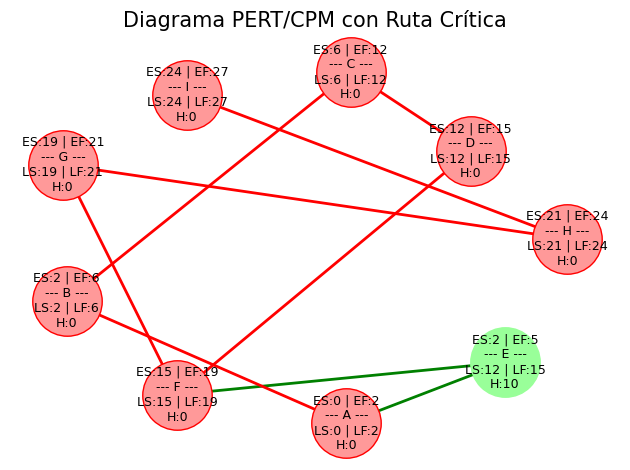

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

grafo = nx.DiGraph()

lista_criticos=[]
lista_normales=[]
informacion={}
for nodo,info in datos.items():
    grafo.add_node(nodo)

    for enlace in info["deps"]:
        grafo.add_edge(enlace,nodo)

    if info["Holgura"]==0:
        lista_criticos.append(nodo)
    else:
        lista_normales.append(nodo)
        
    info = (f"ES:{info['IC']} | EF:{info['TC']}\n"
           f"--- {nodo} ---\n"
           f"LS:{info['IL']} | LF:{info['TL']}\n"
           f"H:{info['Holgura']}")

    informacion[nodo]=info

posiciones = nx.spring_layout(grafo, k=10, seed=50)

print(f"Número de vértices: {grafo.number_of_nodes()}")
print(f"Vértices: {grafo.nodes}")
print(f"Número de aristas: {grafo.number_of_edges()}")
print(f"Vértices: {grafo.edges}")

# 6. Dibujar los Nodos (draw_networkx_nodes)
# Nodos Críticos (Rojo)
nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_criticos, 
                       node_color='#ff9999', # Rojo suave
                       node_size=2500, 
                       node_shape='o', 
                       edgecolors='red')

# Nodos Normales (Azul/Verde)
nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_normales, 
                       node_color='#99ff99', # Verde suave
                       node_size=2500, 
                       node_shape='o')

aristas_criticas = [(u, v) for u, v in grafo.edges() if u in lista_criticos and v in lista_criticos]
aristas_normales = [(u, v) for u, v in grafo.edges() if (u, v) not in aristas_criticas]

nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_normales, edge_color='green', width=2, arrows=True)
nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_criticas, edge_color='red', width=2, arrows=True)

# 8. Dibujar las Etiquetas (Datos alrededor/dentro)
nx.draw_networkx_labels(grafo, posiciones, labels=informacion, font_size=9, font_family="sans-serif")

plt.title("Diagrama PERT/CPM con Ruta Crítica", fontsize=15)
plt.axis('off') # Ocultar ejes X e Y
plt.tight_layout()
plt.show()

### Cronograma (diagrama GANTT)

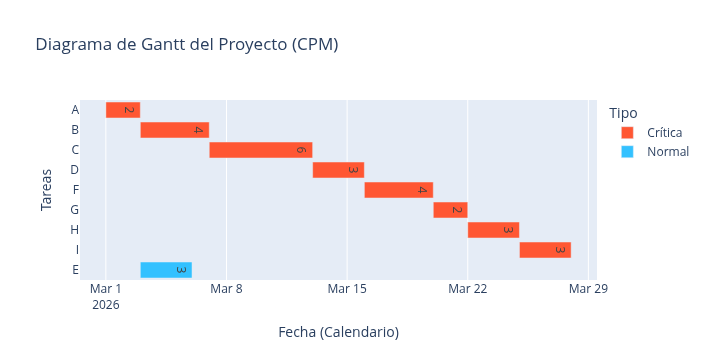

In [10]:
import pandas as pd
import plotly.express as px
from datetime import datetime, timedelta

# fecha de inicio del proyecto (ej. Hoy)
fecha_inicio_proyecto = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)

# 3. Preparar los datos para Plotly (Convertir a DataFrame con Fechas)
lista_tareas = []

for tarea, info in datos.items():
    # Calculamos fechas reales sumando los días (timedelta) a la fecha base
    inicio_real = fecha_inicio_proyecto + timedelta(days=info['IC'])
    fin_real = fecha_inicio_proyecto + timedelta(days=info['TC'])
    
    # Determinamos si es Crítica para el color
    tipo_ruta = "Crítica" if info['Holgura'] == 0 else "Normal"
    
    lista_tareas.append({
        'Tarea': tarea,
        'Inicio': inicio_real,
        'Fin': fin_real,
        'Duracion': info['dur'],
        'Holgura': info['Holgura'],
        'Tipo': tipo_ruta
    })

df_gantt = pd.DataFrame(lista_tareas)

# 4. Generar el Gráfico con Plotly Express
fig = px.timeline(
    df_gantt, 
    x_start="Inicio", 
    x_end="Fin", 
    y="Tarea",
    color="Tipo",  # Colorear según si es crítica o no
    title="Diagrama de Gantt del Proyecto (CPM)",
    hover_data=["Duracion", "Holgura"], # Datos extra al pasar el ratón
    color_discrete_map={"Crítica": "#FF5733", "Normal": "#33C1FF"}, # Rojo y Azul
    text="Duracion" # Muestra la duración dentro de la barra
)

# 5. Ajustes visuales para que "Quede bien"
fig.update_layout(
    xaxis_title="Fecha (Calendario)",
    yaxis_title="Tareas",
    showlegend=True,
    yaxis={'autorange': "reversed"} # IMPORTANTE: Invierte el eje Y para que 'A' salga arriba
)

# Ajustar la posición del texto dentro de las barras
fig.update_traces(textposition='inside')
fig.show()

---
---

### Implementación de personas, recursos y tareas:

In [11]:
datos2 = {
        "A":{
            "rec_hum":{"Ana":1,"Marta":1},
            "desp":{},
            "dur":1.5, # (al 75% de 2)
            "preds": []
        },
        "B":{
            "rec_hum":{"Luis":1},
            "desp":{"Servidor":1},
            "dur":4,
            "preds": ["A"]
        },
        "C":{
            "rec_hum":{"Marta":1},
            "desp":{"Servidor":1},
            "dur":6,
            "preds": ["B"]
        },   
        "D":{
            "rec_hum":{"Ana":1},
            "desp":{"Servidor":1},
            "dur":3,
            "preds": ["C"]
        },    
        "E":{
            "rec_hum":{"Ana":1},
            "desp":{},
            "dur":3,
            "preds": ["A"]
        },    
        "F":{
            "rec_hum":{"Luis":1},
            "desp":{"GPU":1},
            "dur":4,
            "preds": ["D", "E"]
        },
        "G":{
            "rec_hum":{"Ana":1,"Marta":1},
            "desp":{"GPU":1},
            "dur":1.5, # (al 75% de 2)
            "preds": ["F"]
        },
        "H":{
            "rec_hum":{"Pablo":1},
            "desp":{"Banco pruebas":1},
            "dur":3,
            "preds": ["G"]
        },
        "I":{
            "rec_hum":{"Pablo":1,"Marta":1},
            "desp":{"Banco pruebas":1},   
            "dur":2.25, # (al 75% de 3)
            "preds": ["H"]
        },
    }

recursos_totales = {
    "Ana":1, "Marta":1, "Luis":1, "Pablo":1,
    "GPU":1,
    "Banco pruebas":1,
    "Servidor":2 # 2 tareas
}

- b) Para realizar la simulación con recursos limitados, usaremos las siguientes reglas: avanzamos en el tiempo y activamos las distintas tareas si sus dependencias están terminadas y si hay recursos disponibles. Crea por tanto unas estructuras de control que te den información sobre el tiempo de simulación, las tareas en marcha, las tareas finalizadas, los recursos materiales en uso y las personas en uso. Luego crea una función que permita comprobar si una tarea pueda empezar.

In [39]:
def puede_empezar(datos2, recursos_totales, tarea_id, finalizadas):
    tarea = datos2[tarea_id]

    for pred in tarea["preds"]:
        if pred not in finalizadas:
            return False

    requisitos = {**tarea["rec_hum"], **tarea["desp"]}
    for recurso, cantidad_necesaria in requisitos.items():
        if recursos_totales[recurso] < cantidad_necesaria:
            return False

    return True

def simular_proyecto(datos2, recursos_totales):
    tiempo = 0
    tareas_pendientes = list(datos2.keys())
    tareas_en_curso = {}
    tareas_finalizadas = []
    log_gantt = []
    recursos = recursos_totales.copy()
    
    while len(tareas_finalizadas) < len(datos2):    
        acabadas_ahora = [t for t, f in tareas_en_curso.items() if tiempo >= f]

        for tarea in acabadas_ahora:
            tareas_finalizadas.append(tarea)
            reqs = {**datos2[tarea]["rec_hum"], **datos2[tarea]["desp"]}
            for r, c in reqs.items():
                recursos[r] += c
            del tareas_en_curso[tarea]

        empezables = []
        for tarea in tareas_pendientes:
            if puede_empezar(datos2, recursos_totales, tarea, tareas_finalizadas):
                empezables.append(tarea)

        for tarea in empezables:
            reqs = {**datos2[tarea]["rec_hum"], **datos2[tarea]["desp"]}
            for r, c in reqs.items():
                recursos[r] -= c
            
            fin_estimado = tiempo + datos2[tarea]["dur"]
            tareas_en_curso[tarea] = fin_estimado
            tareas_pendientes.remove(tarea)
            log_gantt.append({"Tarea": tarea, "Inicio": tiempo, "Fin": fin_estimado})

        if len(tareas_finalizadas) < len(datos2):
            tiempo += 0.25 # se le suma un valor de 0.25

    return tiempo, log_gantt

duracion_total, resultados = simular_proyecto(datos2, recursos_totales)
print(f"Duración total del proyecto: {duracion_total} días")

# cálculos IC, TC, TL, IL
for res in resultados:
    tarea_id = res["Tarea"]
    datos2[tarea_id]["IC"] = res["Inicio"]
    datos2[tarea_id]["TC"] = res["Fin"]

for clave in reversed(list(datos2.keys())):
    sucesores = [sucesor for sucesor, pred in datos2.items() if clave in pred["preds"]]
    if not sucesores:
        datos2[clave]["TL"] = duracion_total
    else:
        datos2[clave]['TL'] = min([datos2[s]['IL'] for s in sucesores])
    datos2[clave]['IL'] = datos2[clave]['TL'] - datos2[clave]['dur']
    datos2[clave]['Holgura'] = round(datos2[clave]['IL'] - datos2[clave]['IC'], 2)

Duración total del proyecto: 25.25 días


- c) Realiza ahora el análisis simulando el calendario.

In [19]:
import pandas as pd
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

  Tarea  Inicio    Fin
0     A     0.0   1.50
1     B     1.5   5.50
2     E     1.5   4.50
3     C     5.5  11.50
4     D    11.5  14.50
5     F    14.5  18.50
6     G    18.5  20.00
7     H    20.0  23.00
8     I    23.0  25.25


### Grafo

Número de vértices: 9
Vértices: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
Número de aristas: 9
Vértices: [('A', 'B'), ('A', 'E'), ('B', 'C'), ('C', 'D'), ('D', 'F'), ('E', 'F'), ('F', 'G'), ('G', 'H'), ('H', 'I')]


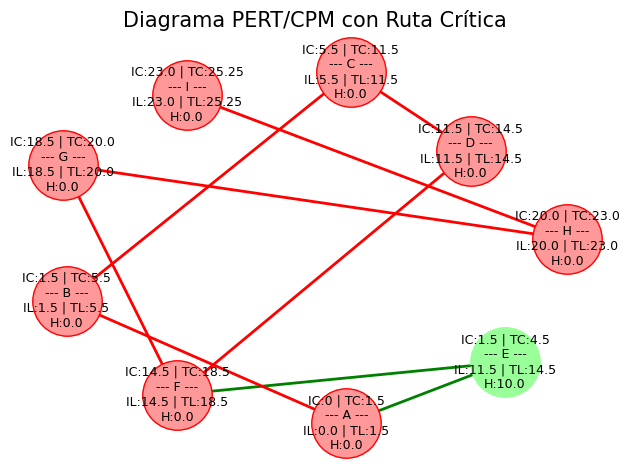

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

camino_critico = ["A", "B", "C", "D", "F", "G", "H", "I"]
grafo = nx.DiGraph()

lista_criticos=[]
lista_normales=[]
informacion={}
for nodo,info in datos2.items():
    grafo.add_node(nodo)

    for enlace in info["preds"]:
        grafo.add_edge(enlace,nodo)

    if nodo in camino_critico:
        lista_criticos.append(nodo)
    else:
        lista_normales.append(nodo)
        
    info = (f"IC:{info['IC']} | TC:{info['TC']}\n"
            f"--- {nodo} ---\n"
            f"IL:{info['IL']} | TL:{info['TL']}\n"
            f"H:{info['Holgura']}")

    informacion[nodo]=info

posiciones = nx.spring_layout(grafo, k=10, seed=50)

print(f"Número de vértices: {grafo.number_of_nodes()}")
print(f"Vértices: {grafo.nodes}")
print(f"Número de aristas: {grafo.number_of_edges()}")
print(f"Vértices: {grafo.edges}")

nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_criticos, 
                       node_color='#ff9999', 
                       node_size=2500, 
                       node_shape='o', 
                       edgecolors='red')


nx.draw_networkx_nodes(grafo, posiciones, 
                       nodelist=lista_normales, 
                       node_color='#99ff99', 
                       node_size=2500, 
                       node_shape='o')

aristas_criticas = [(u, v) for u, v in grafo.edges() if u in lista_criticos and v in lista_criticos]
aristas_normales = [(u, v) for u, v in grafo.edges() if (u, v) not in aristas_criticas]

nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_normales, edge_color='green', width=2, arrows=True)
nx.draw_networkx_edges(grafo, posiciones, edgelist=aristas_criticas, edge_color='red', width=2, arrows=True)

nx.draw_networkx_labels(grafo, posiciones, labels=informacion, font_size=9, font_family="sans-serif")

plt.title("Diagrama PERT/CPM con Ruta Crítica", fontsize=15)
plt.axis('off')
plt.tight_layout()
plt.show()

### Cronograma (diagrama GANTT)

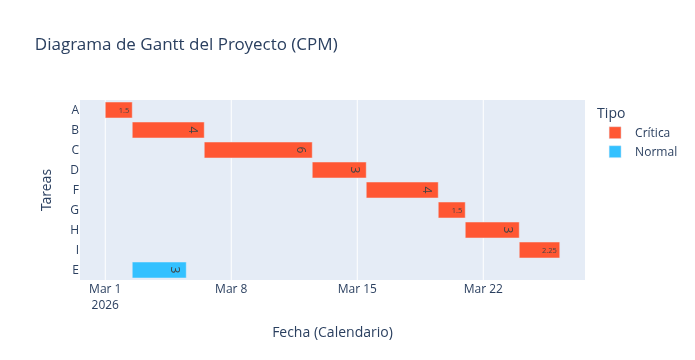

In [41]:
import pandas as pd
import plotly.express as px
from datetime import datetime, timedelta

fecha_inicio_proyecto = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)

lista_tareas = []

for tarea, info in datos2.items():
    
    inicio_real = fecha_inicio_proyecto + timedelta(days=info['IC'])
    fin_real = fecha_inicio_proyecto + timedelta(days=info['TC'])
    
    tipo_ruta = "Crítica" if tarea in camino_critico else "Normal"
    holgura = info["Holgura"]
    
    lista_tareas.append({
        'Tarea': tarea,
        'Inicio': inicio_real,
        'Fin': fin_real,
        'Duracion': info['dur'],
        'Holgura': holgura,
        'Tipo': tipo_ruta
    })

df_gantt = pd.DataFrame(lista_tareas)

fig = px.timeline(
    df_gantt, 
    x_start="Inicio", 
    x_end="Fin", 
    y="Tarea",
    color="Tipo",  
    title="Diagrama de Gantt del Proyecto (CPM)",
    hover_data=["Duracion", "Holgura"], 
    color_discrete_map={"Crítica": "#FF5733", "Normal": "#33C1FF"}, 
    text="Duracion" 
)


fig.update_layout(
    xaxis_title="Fecha (Calendario)",
    yaxis_title="Tareas",
    showlegend=True,
    yaxis={'autorange': "reversed"}
)


fig.update_traces(textposition='inside')
fig.show()

- d) ¿Es la duración del proyecto la misma en ambos casos?
    - **No.** Al tener unos porcentajes del 75% de reducción en la duración de tareas con 2 personas $(A, G, I)$, el proyecto se ve reucido a 25.25 días < 27 días sin la reducción del 75%. *Por lo que, disminuye la duración*.

- e) Preguntas para discusión:
    - a. ¿Qué recurso es el cuello de botella?
        - Marta es el cuello de botella. Al no tener una disponibilidad del 100%, retrasa el proyecto.
    - b. ¿Qué tarea limita el proyecto realmente?
        - La tarea que limita el proyecto es la **C**, si hubiese otra persona se podría realizar con mayor rapidez. No retrasaría tanto el proyecto.
    - c. ¿Es mejor añadir otra GPU o más personas?
        - Más personas. Las GPUs no influyen tanto como las personas en la reducción del proyecto.
    - d. ¿Qué ocurre si Marta aumenta su disponibilidad al 100%?
        - Nada prácticamente. Podría tener menor duración pero no es una condición clara el aumento de su disponibilidad a la duración total del proyecto. Una ampliación de personas o recursos sí modificaría de forma correcta la duración del proyecto.